In [3]:
# Pandas library ko import kar rahe hain data handle karne ke liye
import pandas as pd

# Dataset ko load kar rahe hain
# '../' ka matlab hai ek folder bahar aana, aur fir 'Dataset' folder mein jana
df = pd.read_csv('../Dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv')

# Data ki shuruaati 5 rows ko print karke check karte hain
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [4]:
# 1. Dataset ki shape (rows aur columns) check karna
print("Dataset ki total rows aur columns:", df.shape)

# 2. Missing values check karna
print("Total Missing Values:", df.isnull().sum().sum())

# 3. Duplicate rows check karna
print("Total Duplicate Rows:", df.duplicated().sum())

# 4. Useless columns ko drop karna (jinki model ko zaroorat nahi)
useless_columns = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']
df = df.drop(columns=useless_columns)

# Drop karne ke baad nayi shape check karna
print("\nColumns drop karne ke baad nayi shape:", df.shape)

Dataset ki total rows aur columns: (1470, 35)
Total Missing Values: 0
Total Duplicate Rows: 0

Columns drop karne ke baad nayi shape: (1470, 31)


In [5]:
# Import LabelEncoder to convert categorical text data into numerical format
from sklearn.preprocessing import LabelEncoder

# Initialize the encoder
le = LabelEncoder()

# Convert the 'Attrition' column values ('Yes'/'No') to binary format (1/0)
df['Attrition'] = le.fit_transform(df['Attrition'])

# Display the first 5 rows to verify the changes
df[['Age', 'Attrition', 'Department', 'Gender']].head()

,Age,Attrition,Department,Gender
0,41,1,Sales,Female
1,49,0,Research & Development,Male
2,37,1,Research & Development,Male
3,33,0,Research & Development,Female
4,27,0,Research & Development,Male


In [7]:
!pip install scikit-learn seaborn matplotlib imbalanced-learn xgboost

   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.2 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.2 MB 1.2 MB/s eta 0:00:07
   -- ------------------------------------- 0.5/8.2 MB 1.2 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.2 MB 827.9 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.2 MB 827.9 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.2 MB 827.9 kB/s eta 0:00:09
   --- ------------------------------------ 0.8/8.2 MB 827.9 kB/s eta 0:00:09
   ----- ---------------------------------- 1.0/8.2 MB 534.0 kB/s eta 0:00:14
   ----- ---------------------------------- 1.0/8.2 MB 534.0 kB/s eta 0:00:14
   ----- ---------------------------------- 1.0/8.2 MB 534.0 kB/s eta 0:00:14
   ----- ---------------------------------- 1.0/8.2 MB 534.0 kB/s eta 0:00:14
   ------ 


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_19760\2104501981.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, ax=axes[0], palette='viridis')


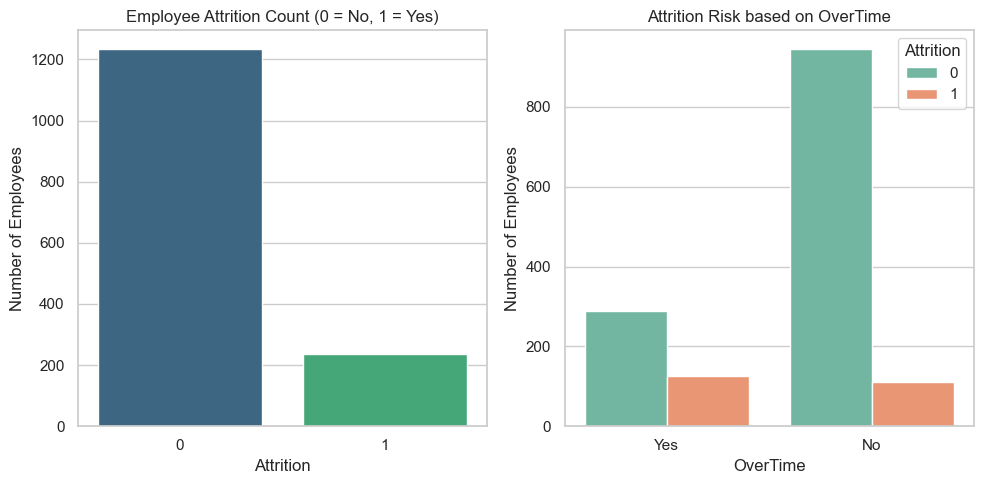

In [6]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style for the plots to make them look professional
sns.set_theme(style="whitegrid")

# Create a figure with two subplots side by side
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# Graph 1: Distribution of the target variable (Attrition)
# This shows how many employees left (1) vs stayed (0)
sns.countplot(x='Attrition', data=df, ax=axes[0], palette='viridis')
axes[0].set_title('Employee Attrition Count (0 = No, 1 = Yes)')
axes[0].set_ylabel('Number of Employees')

# Graph 2: Impact of OverTime on Attrition
# This helps us understand if working overtime increases the risk of leaving
sns.countplot(x='OverTime', hue='Attrition', data=df, ax=axes[1], palette='Set2')
axes[1].set_title('Attrition Risk based on OverTime')
axes[1].set_ylabel('Number of Employees')

# Display the plots
plt.tight_layout()
plt.show()

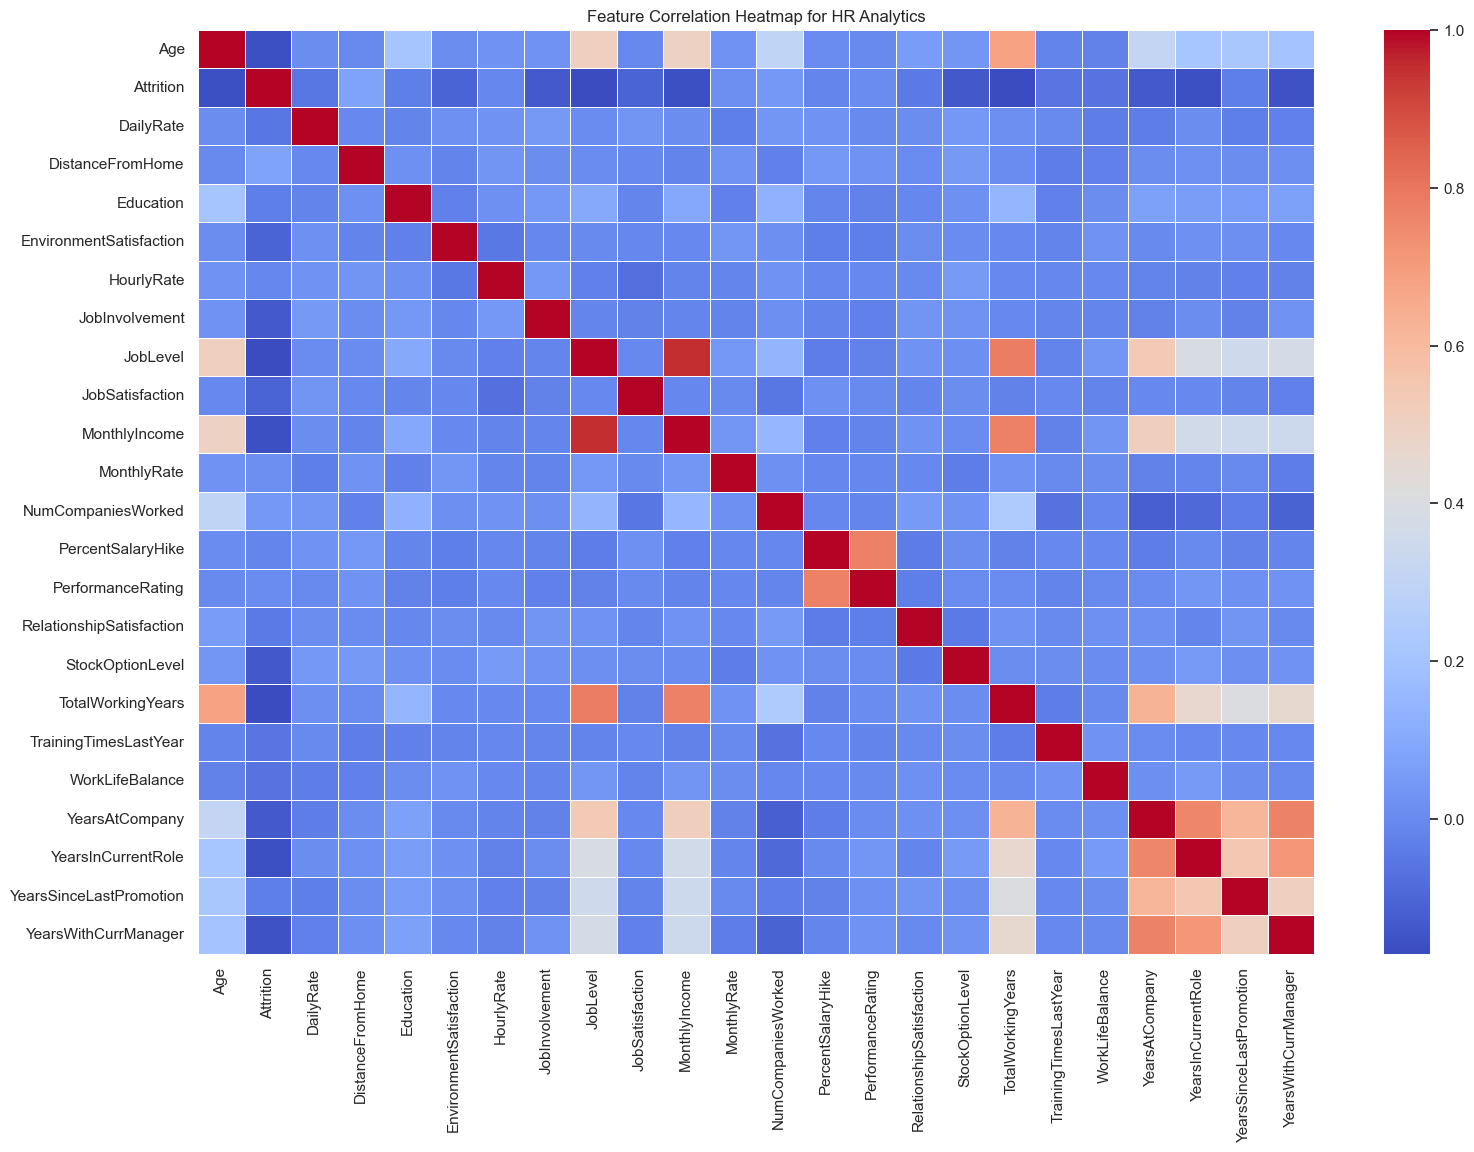

In [7]:
# Import necessary libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numerical columns for correlation calculation
# Categorical (text) columns cannot be used to find mathematical correlation
numeric_cols = df.select_dtypes(include=['int32', 'int64', 'float64'])

# Calculate the correlation matrix
correlation_matrix = numeric_cols.corr()

# Set up the matplotlib figure size
plt.figure(figsize=(18, 12))

# Generate a custom heatmap using Seaborn
# annot=False keeps it clean (without numbers in boxes) due to many columns
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', linewidths=0.5)

# Add a title to the visualization
plt.title('Feature Correlation Heatmap for HR Analytics')

# Display the heatmap
plt.show()

In [8]:
# Create a copy of the dataframe to avoid any warnings
df_engineered = df.copy()

# 1. Feature Engineering: Creating new actionable business features 
# Calculate the ratio of years spent at the current company vs total working years
df_engineered['YearsAtCompanyRatio'] = df_engineered['YearsAtCompany'] / df_engineered['TotalWorkingYears'].replace(0, 1)

# Calculate how many years an employee has stayed since their last promotion
df_engineered['PromotionDelay'] = df_engineered['YearsAtCompany'] - df_engineered['YearsSinceLastPromotion']

# Create a risk index by combining different satisfaction metrics (Lower score = Higher Risk)
df_engineered['WorkLifeRiskIndex'] = df_engineered['JobSatisfaction'] + df_engineered['EnvironmentSatisfaction'] + df_engineered['WorkLifeBalance']

# 2. One-Hot Encoding: Convert remaining text categorical columns into binary (0 and 1) 
# Get the list of columns that still have text data (object type)
categorical_cols = df_engineered.select_dtypes(include=['object']).columns

# Use pandas get_dummies to create binary columns for every text category
# drop_first=True is used to avoid the dummy variable trap
df_final = pd.get_dummies(df_engineered, columns=categorical_cols, drop_first=True)

# Display the new shape of the dataset to see how many new columns were added
print("Original Data Shape:", df.shape)
print("New Data Shape after Feature Engineering & Encoding:", df_final.shape)

Original Data Shape: (1470, 31)
New Data Shape after Feature Engineering & Encoding: (1470, 48)


In [9]:
# Import necessary modules for splitting, scaling, and handling imbalanced data
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Separate the Features (X) and the Target variable (y)
# X contains all columns except 'Attrition' (our inputs)
# y contains only the 'Attrition' column (what we want to predict)
X = df_final.drop('Attrition', axis=1)
y = df_final['Attrition']

# 2. Split the dataset into Training set (80%) and Testing set (20%)
# stratify=y ensures the same ratio of Yes/No goes into both sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Initialize SMOTE to handle the class imbalance seen in our EDA Phase
# SMOTE will create synthetic samples for the minority class (employees who left)
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY to the Training data (We never touch the Testing data to keep it a fair exam)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# 4. Initialize StandardScaler to bring all numerical values to a similar scale
# This helps algorithms like XGBoost and Logistic Regression perform better
scaler = StandardScaler()

# Fit the scaler on the training data and transform it
X_train_scaled = scaler.fit_transform(X_train_smote)

# Only transform the testing data (Do NOT fit it on test data to prevent data leakage)
X_test_scaled = scaler.transform(X_test)

# Display the shape of the data before and after SMOTE
print("Original Training Data Shape (Before SMOTE):", X_train.shape)
print("Balanced Training Data Shape (After SMOTE):", X_train_scaled.shape)

Original Training Data Shape (Before SMOTE): (1176, 47)
Balanced Training Data Shape (After SMOTE): (1972, 47)


In [10]:
# Import Machine Learning algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Import Evaluation Metrics to test our models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# 1. Initialize the 3 Machine Learning Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

# 2. Create an empty list to store the report cards of our models
results = []

# 3. Train and Test each model using a loop
for model_name, model in models.items():
    # 'fit' means training the model on the balanced data (Studying for the exam)
    model.fit(X_train_scaled, y_train_smote)
    
    # 'predict' means taking the test on the unseen 20% data (Giving the actual exam)
    y_pred = model.predict(X_test_scaled)
    
    # Calculate the marks (Metrics)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    # Store the results
    results.append({
        "Model Name": model_name,
        "Accuracy": round(accuracy, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1 Score": round(f1, 3)
    })

# 4. Display the Final Comparison Report as a clean table
results_df = pd.DataFrame(results)
print("--- MACHINE LEARNING MODELS EVALUATION REPORT ---")
display(results_df)

--- MACHINE LEARNING MODELS EVALUATION REPORT ---


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:200: UserWarning: [00:44:56] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,Model Name,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.878,0.690,0.426,0.526
1,Random Forest,0.867,0.654,0.362,0.466
2,XGBoost,0.867,0.654,0.362,0.466


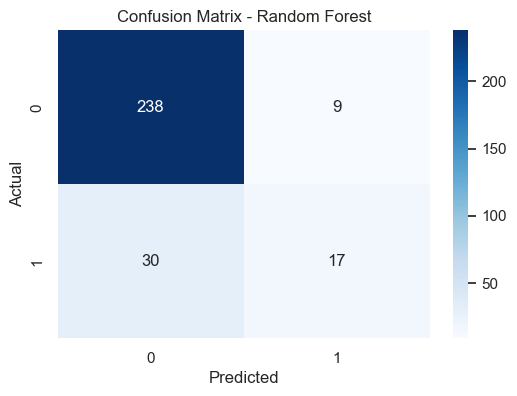

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Tumhare 'models' dictionary se sirf Random Forest ko nikalna
rf_model = models["Random Forest"]

# 2. Sirf Random Forest se dubara prediction karwana
y_pred_rf = rf_model.predict(X_test_scaled)

# 3. Confusion Matrix ka graph plot karna
cm = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [15]:
# Import pickle and os libraries for saving files securely
import pickle
import os

# 1. Re-train the best performing model (Logistic Regression) to ensure it's fresh
best_model = LogisticRegression(random_state=42)
best_model.fit(X_train_scaled, y_train_smote)

# 2. Check and create the 'Model' folder if it doesn't exist (Safety check)
os.makedirs('../Model', exist_ok=True)

# 3. Save the trained model as a .pkl file in the Model folder
# 'wb' means Write Binary (saving in a machine-readable format)
with open('../Model/attrition_model.pkl', 'wb') as model_file:
    pickle.dump(best_model, model_file)

# 4. Save the scaler as well
# The scaler is strictly required to process new employee data exactly like the training data
with open('../Model/scaler.pkl', 'wb') as scaler_file:
    pickle.dump(scaler, scaler_file)

# 5. Save the final list of columns to ensure the web app asks for the exact same inputs
feature_columns = X.columns.tolist()
with open('../Model/features.pkl', 'wb') as feature_file:
    pickle.dump(feature_columns, feature_file)

print("SUCCESS! Model, Scaler, and Features have been saved in the 'Model' folder.")

SUCCESS! Model, Scaler, and Features have been saved in the 'Model' folder.
